In [2]:
# import the all libraries
import pandas as pd
import numpy as nm 
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')


In [3]:
# load the dataset 
df=pd.read_csv(r"C:\Users\Prince\OneDrive\Desktop\Pakistan_Online_Product_Sales.csv")

In [8]:
# overview of the dataset
df.head(10)

,ProductID,ProductName,Category,Price,UnitsSold,Rating
0,1,Product_1,Books,598.73,342,4.5
1,2,Product_2,Beauty,849.01,316,1.9
2,3,Product_3,Home & Kitchen,1305.19,101,2.4
3,4,Product_4,Beauty,887.34,244,1.3
4,5,Product_5,Beauty,1014.18,490,4.1
5,6,Product_6,Clothing,1496.97,12,2.6
6,7,Product_7,Home & Kitchen,949.53,239,4.0
7,8,Product_8,Home & Kitchen,4494.15,49,4.6
8,9,Product_9,Home & Kitchen,493.15,42,1.9
9,10,Product_10,Beauty,2670.11,166,4.2


In [4]:
df.tail(10)

,ProductID,ProductName,Category,Price,UnitsSold,Rating
990,991,Product_991,Clothing,529.45,148,3.9
991,992,Product_992,Clothing,4691.09,124,1.0
992,993,Product_993,Home & Kitchen,2813.63,1,2.6
993,994,Product_994,Home & Kitchen,1597.07,456,4.7
994,995,Product_995,Beauty,2045.21,247,1.4
995,996,Product_996,Sports,2291.29,343,3.1
996,997,Product_997,Beauty,3042.91,128,4.1
997,998,Product_998,Electronics,2626.83,191,4.8
998,999,Product_999,Electronics,4605.02,67,4.0
999,1000,Product_1000,Beauty,2535.12,4,3.9


In [5]:
# no. of rows and columns 
df.shape

(1000, 6)

In [6]:
# Namme and types of variables 
df.info

<bound method DataFrame.info of      ProductID   ProductName        Category    Price  UnitsSold  Rating
0            1     Product_1           Books   598.73        342     4.5
1            2     Product_2          Beauty   849.01        316     1.9
2            3     Product_3  Home & Kitchen  1305.19        101     2.4
3            4     Product_4          Beauty   887.34        244     1.3
4            5     Product_5          Beauty  1014.18        490     4.1
..         ...           ...             ...      ...        ...     ...
995        996   Product_996          Sports  2291.29        343     3.1
996        997   Product_997          Beauty  3042.91        128     4.1
997        998   Product_998     Electronics  2626.83        191     4.8
998        999   Product_999     Electronics  4605.02         67     4.0
999       1000  Product_1000          Beauty  2535.12          4     3.9

[1000 rows x 6 columns]>

In [15]:
# Data cleaning 
df.isnull().sum()

ProductID      0
ProductName    0
Category       0
Price          0
UnitsSold      0
Rating         0
dtype: int64

In [16]:
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())
print("\nUnique values in 'Category':")
print(df['Category'].unique())


Number of duplicate rows:
0

Unique values in 'Category':
['Books' 'Beauty' 'Home & Kitchen' 'Clothing' 'Sports' 'Electronics']


In [31]:
# Summary statistics
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ProductID,1000.0,500.50000,288.819436,1.0,250.7500,500.50,750.2500,1000.00
Price,1000.0,2551.31121,1423.726398,122.7,1263.1375,2586.94,3743.7275,4997.13
UnitsSold,1000.0,248.62900,145.349888,1.0,121.7500,246.00,383.0000,499.00
Rating,1000.0,3.03600,1.157758,1.0,2.0000,3.10,4.0000,5.00


In [34]:
def calculate_summary_statistics(series, name):
    """Calculates Mean, Median, Mode, Std Dev, Min, Max, and Range for a series."""
    stats = {
        'Variable': name,
        'Mean': series.mean(),
        'Median': series.median(),
        # Get the first mode if multiple exist, or 'N/A' if mode is empty
        'Mode': series.mode().iloc[0] if not series.mode().empty else 'N/A',
        'Standard Deviation': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        'Range': series.max() - series.min()
    }
    return stats

# Calculate statistics for 'Price' and 'UnitsSold'
price_stats = calculate_summary_statistics(df['Price'], 'Price')
units_sold_stats = calculate_summary_statistics(df['UnitsSold'], 'UnitsSold')

# Create a DataFrame for a neat table presentation
summary_df = pd.DataFrame([price_stats, units_sold_stats])

print("--- Summary Statistics for Price and UnitsSold ---")
print(summary_df.set_index('Variable').to_markdown(numalign="left", stralign="left"))

--- Summary Statistics for Price and UnitsSold ---
| Variable   | Mean    | Median   | Mode   | Standard Deviation   | Min   | Max     | Range   |
|:-----------|:--------|:---------|:-------|:---------------------|:------|:--------|:--------|
| Price      | 2551.31 | 2586.94  | 122.7  | 1423.73              | 122.7 | 4997.13 | 4874.43 |
| UnitsSold  | 248.629 | 246      | 405    | 145.35               | 1     | 499     | 498     |


In [6]:
num_cols=['Price' , 'UnitsSold' , 'Rating']
df[num_cols].describe()

,Price,UnitsSold,Rating
count,1000.000000,1000.000000,1000.000000
mean,2551.311210,248.629000,3.036000
std,1423.726398,145.349888,1.157758
min,122.700000,1.000000,1.000000
25%,1263.137500,121.750000,2.000000
50%,2586.940000,246.000000,3.100000
75%,3743.727500,383.000000,4.000000
max,4997.130000,499.000000,5.000000


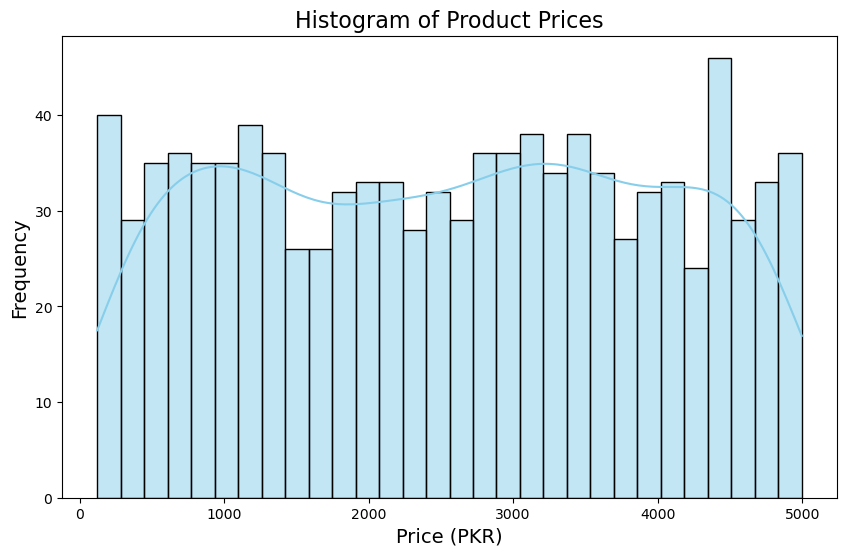

In [9]:
# Univariate Analysis Code

# 4.1 Histogram for Price (Numeric Column)
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of Product Prices', fontsize=16)
plt.xlabel('Price (PKR)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

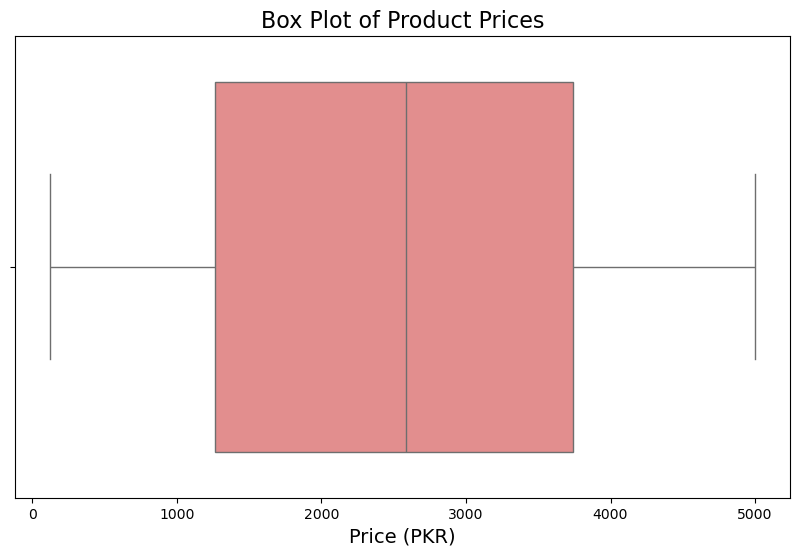

In [8]:
# 4.2 Box Plot for Price (Numeric Column)
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Price'], color='lightcoral')
plt.title('Box Plot of Product Prices', fontsize=16)
plt.xlabel('Price (PKR)', fontsize=14)
plt.show()


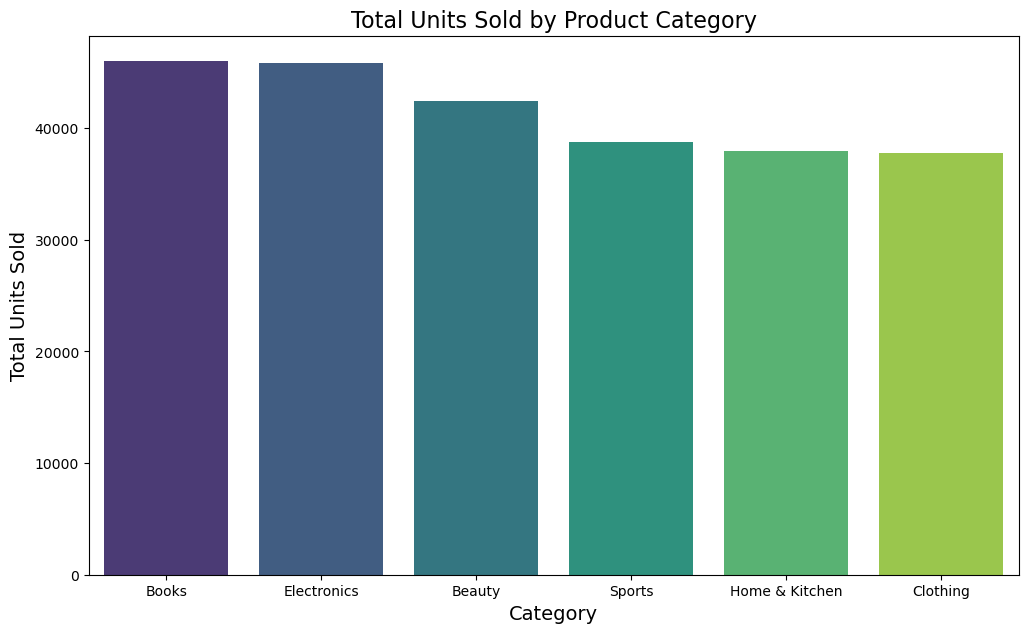

In [10]:
# 4.3 Bar Chart for Category (Categorical Column)
category_sales = df.groupby('Category')['UnitsSold'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Units Sold by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Total Units Sold', fontsize=14)
plt.show()

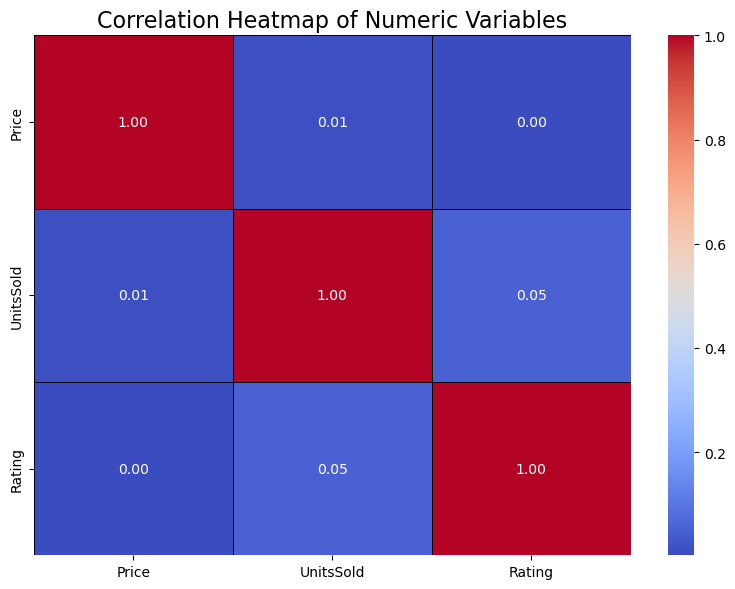

In [6]:
# BIVARIATE ANALYSIS 
# Correlation Heatmap Code
numeric_df = df[['Price', 'UnitsSold', 'Rating']]
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Correlation Heatmap of Numeric Variables', fontsize=16)
plt.show()

                      Price
Category                   
Beauty          2766.502791
Books           2466.857586
Clothing        2540.748902
Electronics     2480.838343
Home & Kitchen  2404.446429
Sports          2646.710968


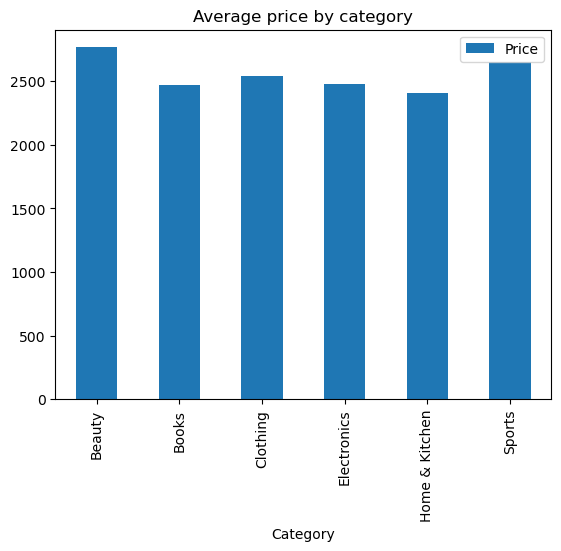

In [13]:
#PIVOT TABLE  WITH PIVOT CHART SHOWING RELATOINSHIP/ COMPARISON between Category and Rating 
pivot=df.pivot_table(values='Price',index='Category', aggfunc='mean')
print(pivot)

pivot.plot(kind='bar', title="Average price by category")
plt.show()